# Customer Segmentation Project

## Customer Segmentation Using Purchase Behavior

This project uses historical retail transaction data to segment customers based on their purchase behavior and identify key characteristics of each customer segment.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



## 1. Importing the Dataset

The historical retail transaction dataset is loaded to analyze customer purchase behavior and create customer segments.

In [18]:
df_2009_2010 = pd.read_excel(
    "online_retail_II.xlsx",
    sheet_name="Year 2009-2010"
)

df_2010_2011 = pd.read_excel(
    "online_retail_II.xlsx",
    sheet_name="Year 2010-2011"
)

df = pd.concat(
    [df_2009_2010, df_2010_2011],
    ignore_index=True
)

print("Dataset shape:", df.shape)

Dataset shape: (1067371, 8)


## 2. Data Cleaning

The dataset is cleaned by removing duplicate transactions, handling missing customer information, and removing invalid quantities and prices before customer segmentation.

In [19]:
# Remove duplicate transactions
df = df.drop_duplicates()

df = df.dropna(subset=["Customer ID"])

# Keep only valid purchases
df = df[(df["Quantity"] > 0) & (df["Price"] > 0)]

print("Cleaned dataset shape:", df.shape)

Cleaned dataset shape: (779425, 8)


## 3. Customer Purchase Behavior

Customer-level purchase data is created to identify differences in purchasing patterns and form meaningful customer segments.

In [20]:
df["Total_Sales"] = df["Quantity"] * df["Price"]

customer_data = df.groupby("Customer ID").agg(
    Total_Quantity=("Quantity", "sum"),
    Total_Spending=("Total_Sales", "sum"),
    Purchase_Frequency=("Invoice", "nunique")
).reset_index()

customer_data.head()

,Customer ID,Total_Quantity,Total_Spending,Purchase_Frequency
0,12346.0,74285,77556.46,12
1,12347.0,2967,4921.53,8
2,12348.0,2714,2019.40,5
3,12349.0,1624,4428.69,4
4,12350.0,197,334.40,1


## 4. Preparing Data for Clustering

The customer purchase measures are prepared for clustering so that customers with different purchasing patterns can be grouped into similar segments.

In [21]:

X = customer_data[
    ["Total_Quantity", "Total_Spending", "Purchase_Frequency"]
].values

# Standardize the features
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)

X_scaled = (X - X_mean) / X_std

print("Data prepared for clustering.")
print("Shape:", X_scaled.shape)

Data prepared for clustering.
Shape: (5878, 3)


## 5. Customer Clustering

K-Means clustering is applied to group customers with similar purchase behavior into distinct customer segments.

In [22]:
# K-Means clustering using NumPy

k = 4

# Initialize cluster centers
np.random.seed(42)
centers = X_scaled[np.random.choice(len(X_scaled), k, replace=False)]

for _ in range(100):
    # Calculate distance from each customer to each cluster center
    distances = np.sqrt(
        ((X_scaled[:, np.newaxis, :] - centers) ** 2).sum(axis=2)
    )

    # Assign each customer to the nearest cluster
    labels = np.argmin(distances, axis=1)

    # Calculate new cluster centers
    new_centers = np.array([
        X_scaled[labels == i].mean(axis=0)
        if np.any(labels == i)
        else centers[i]
        for i in range(k)
    ])

    # Stop if centers no longer change
    if np.allclose(centers, new_centers):
        break

    centers = new_centers

customer_data["Segment"] = labels

print("Customer clustering completed.")
print("\nCustomers in each segment:")
print(customer_data["Segment"].value_counts().sort_index())

Customer clustering completed.

Customers in each segment:
Segment
0      28
1       5
2     424
3    5421
Name: count, dtype: int64


## 6. Segment Characteristics

The purchase behavior of each customer segment is analyzed using total quantity, total spending, and purchase frequency.

In [23]:
segment_summary = customer_data.groupby("Segment")[
    ["Total_Quantity", "Total_Spending", "Purchase_Frequency"]
].mean().round(2)

segment_summary

,Total_Quantity,Total_Spending,Purchase_Frequency
Segment,,,
0,70363.46,89128.06,91.18
1,209867.20,382017.74,198.60
2,7330.29,12880.86,27.70
3,809.15,1384.92,4.00


## 7. Visualizing Customer Segments

The customer segments are visualized to compare their purchase behavior and understand the differences between the segments.

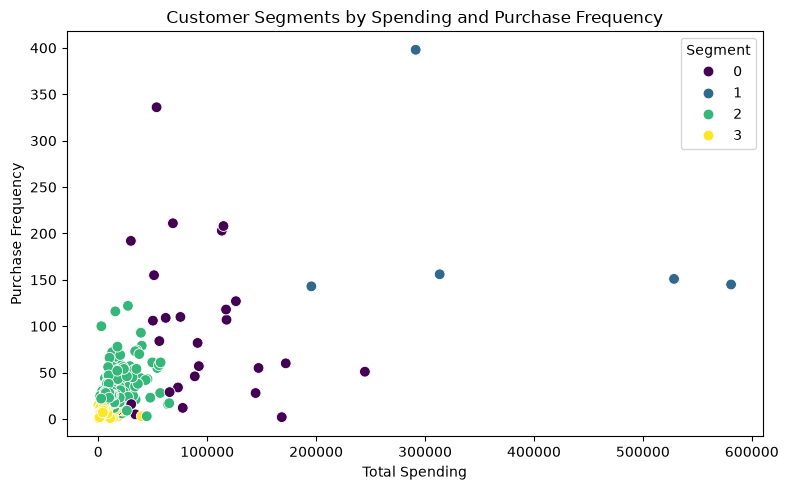

In [24]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=customer_data,
    x="Total_Spending",
    y="Purchase_Frequency",
    hue="Segment",
    palette="viridis",
    s=60
)

plt.title("Customer Segments by Spending and Purchase Frequency")
plt.xlabel("Total Spending")
plt.ylabel("Purchase Frequency")
plt.legend(title="Segment")
plt.tight_layout()
plt.show()

## 8. Segment Characteristics Visualization

The average purchase behavior of each customer segment is visualized to compare total quantity, total spending, and purchase frequency.

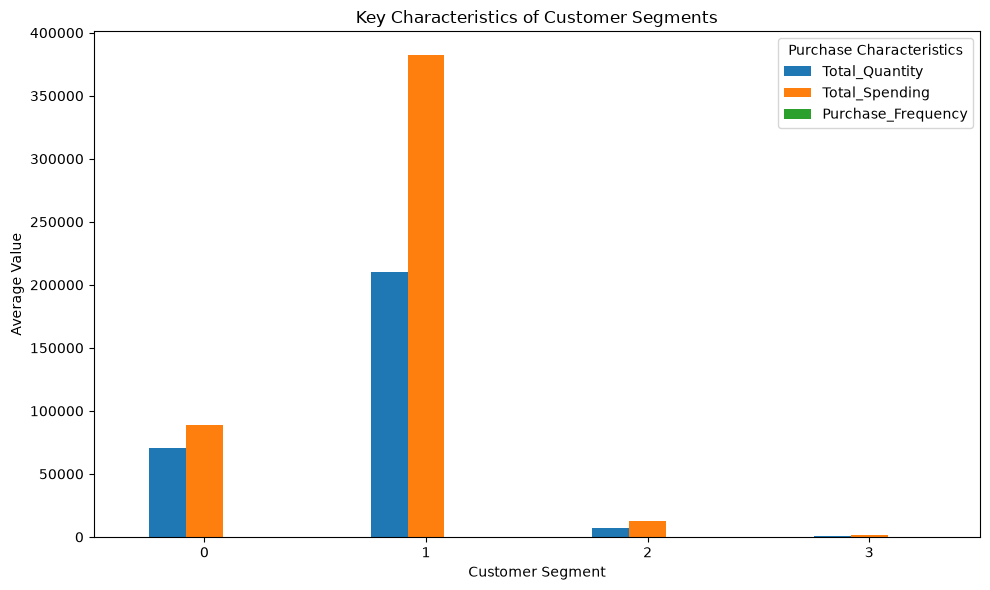

In [25]:
# Visualize average purchase behavior by segment

segment_summary.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Key Characteristics of Customer Segments")
plt.xlabel("Customer Segment")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(title="Purchase Characteristics")
plt.tight_layout()
plt.show()

## 9. Conclusion

The retail transaction data was cleaned and customer-level purchase behavior was prepared using total quantity, total spending, and purchase frequency.

K-Means clustering was used to divide customers into four segments based on their purchasing patterns.

The segments were analyzed and visualized to understand differences in customer purchase behavior and key characteristics.

This project provided practical experience in customer analytics, clustering, customer segmentation, and visualization.